# Multivariate Regression Covid

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [4]:
df['country'].unique()

array(['Chile', 'Colombia', 'Italy', 'Mexico', 'US'], dtype=object)

In [5]:
import json
from pathlib import Path

# path to the JSON file
json_path = Path("..") / "Data" / "gold" / "features_dict.json"

# read it into a Python dict
with json_path.open("r", encoding="utf‑8") as f:
    features_dict = json.load(f)

# quick sanity check
print(f"Loaded {len(features_dict)} keys from features_dict.json")

Loaded 2 keys from features_dict.json


In [6]:
selected_features_covid = features_dict['covid_col']

In [7]:
selected_features_covid

['new_cases', 'google_symptom', 'o3', 'pop_vaccinated', 'no2']

In [8]:
selected_features_covid.extend(['date', 'country'])

# Wrangle

In [9]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [10]:
df = df[selected_features_covid]

In [11]:
df['cases_t_1'] = df.groupby('country')['new_cases'].shift(-1)

In [12]:
# ------------------------------------------------------------------
# 1.  Sort once so groupby‑shift/rolling are correct
# ------------------------------------------------------------------
df = df.sort_values(['country', 'date']).reset_index(drop=True)

# ------------------------------------------------------------------
# 2.  Create lag‑1 and lag‑2 features for the weekly target
#     (replace 'cases_t_1' with your true target column name
#      if it differs) 
# ------------------------------------------------------------------
for lag in [1, 2]:
    df[f'cases_lag_{lag}'] = (
        df.groupby('country')['cases_t_1']
          .shift(lag)
    )

# ------------------------------------------------------------------
# 3.  Two‑period rolling mean of the *previous* weeks
#     (window=2, min_periods=1 lets the first available lag
#      propagate instead of NaN)
# ------------------------------------------------------------------
df['cases_roll_mean_2'] = (
    df.groupby('country')['cases_t_1']
      .shift(1)                      # exclude the current week
      .rolling(window=2, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)   # drop group index after rolling
)

# Optional: fill remaining NaNs after the very first week for each country
df = df.dropna(subset=['cases_t_1'])
df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer

C:\Users\danie\AppData\Local\Temp\ipykernel_15328\2134973485.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer


In [13]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())
df['month'] = df['date'].dt.month



In [14]:
df_og = df.copy()

# Regression Framework

In [15]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## OLS

In [30]:
from sklearn.linear_model import LinearRegression
df = df_og.copy()

    country           rmse        r2
0     Chile   14587.943493  0.296158
1  Colombia   12252.265833 -1.119249
2     Italy   54492.565692  0.880333
3    Mexico   34587.809795  0.639214
4        US  271582.574130 -0.480838
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23   2420.000012   783.000024  31258.999979   1150.000007   
2020-03-30  11957.567935  8842.942520  54415.433168  18089.428801   
2020-04-06   8790.339632  8259.815068  29932.134668  11994.864167   
2020-04-13   4768.372694 -5034.504496  14544.649663  -1377.857186   
2020-04-20   5024.798130 -4495.864320  22932.032064   4184.750679   

country                US  
date                       
2020-03-23  209572.999995  
2020-03-30  124982.252202  
2020-04-06  150831.627279  
2020-04-13  110692.217909  
2020-04-20  143810.421108  


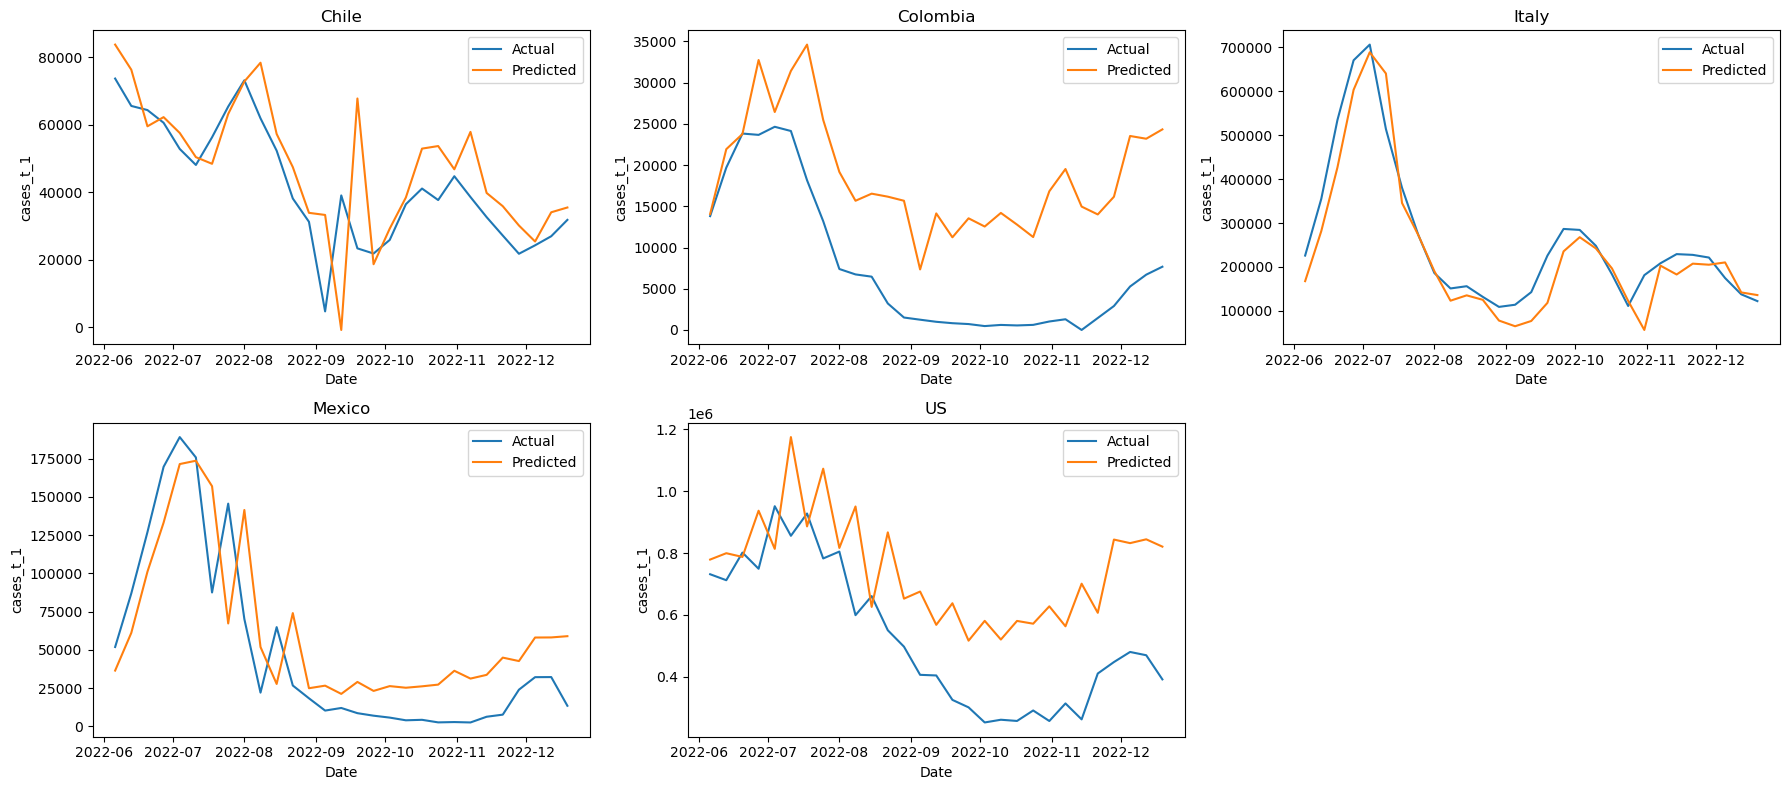

In [31]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for plotting
fit_records   = []   # date‑wise fitted values —> will pivot later

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date'])
    X = X.select_dtypes(include='number')

    # ---- 1.3  Chronological 80 / 20 split  ---------------------
    split_pt = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Fit Linear Regression
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = linreg.predict(X_test)
    y_pred_train = linreg.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values for *all* rows (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table (unchanged)
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  ← NEW
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)          # long
      .pivot(index='date', columns='country', values='fitted')  # wide
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot section (unchanged)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

In [32]:
fitted_df.to_csv('../results/OLS_covid.csv', index = True)

## Lasso

In [33]:
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV
df = df_og.copy()


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.483e+08, tolerance: 6.592e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.131e+10, tolerance: 9.662e+09
  model = cd_fast.enet_coordinate_descent(


    country           rmse        r2       alpha
0     Chile   14341.559138  0.319733   43.025587
1  Colombia    9432.827449 -0.256125  276.083804
2     Italy   51760.220161  0.892033  301.083456
3    Mexico   34108.745943  0.649139  108.159557
4        US  261849.303030 -0.376597  847.482466
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23  11759.433329  7330.136451  87553.720845   6239.521721   
2020-03-30  11436.249767  8943.519944  42526.025239  18434.687237   
2020-04-06   8505.654746  8452.355600  21425.388078  12465.340176   
2020-04-13   4642.440848 -4614.779491   4926.985465   -756.351355   
2020-04-20   5042.938274 -3156.185115  12431.816607   4699.507677   

country                US  
date                       
2020-03-23   92154.046105  
2020-03-30  148274.873095  
2020-04-06  167439.347733  
2020-04-13  126635.078547  
2020-04-20  158655.158397  


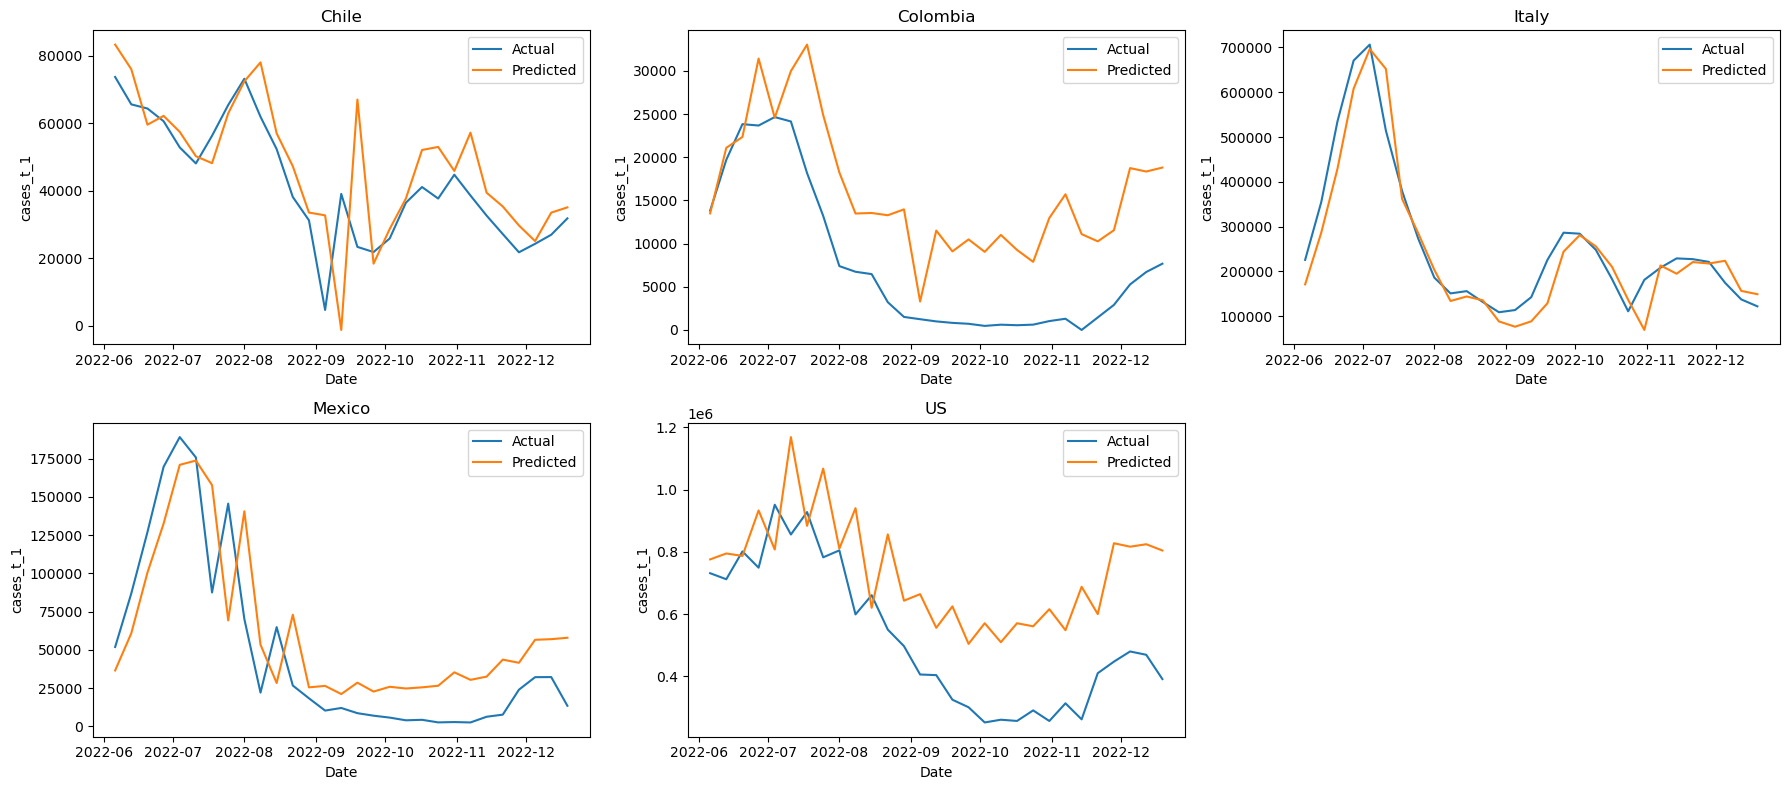

In [34]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date']).select_dtypes(include='number')

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: scaler → LassoCV
    #           inner CV keeps order (3 folds on TRAIN only)
    inner_cv = TimeSeriesSplit(n_splits=3)

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LassoCV(cv=inner_cv,
                           random_state=42,
                           n_alphas=50,
                           max_iter=5000))
    ])

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [35]:
# store results
fitted_df.to_csv('../results/Lasso_covid.csv', index = True)

## Ridge

In [37]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()

    country           rmse        r2     alpha
0     Chile   15063.766423  0.249494  0.028072
1  Colombia    9790.525212 -0.353197  2.043360
2     Italy   54212.686995  0.881559  0.001000
3    Mexico   34501.358561  0.641015  0.188739
4        US  271296.400453 -0.477719  0.001000
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23  10966.811928  8495.228624  38099.444104   2681.151620   
2020-03-30  10834.013104  8320.304221  53612.180292  18196.358650   
2020-04-06   7836.480658  7351.162173  29371.075463  12087.960321   
2020-04-13   4123.739582 -6428.673416  13898.912977  -1302.114717   
2020-04-20   4243.169404 -4650.559515  22204.805564   4220.121269   

country                US  
date                       
2020-03-23  205001.631280  
2020-03-30  126068.519282  
2020-04-06  151532.600355  
2020-04-13  111323.333398  
2020-04-20  144412.566286  


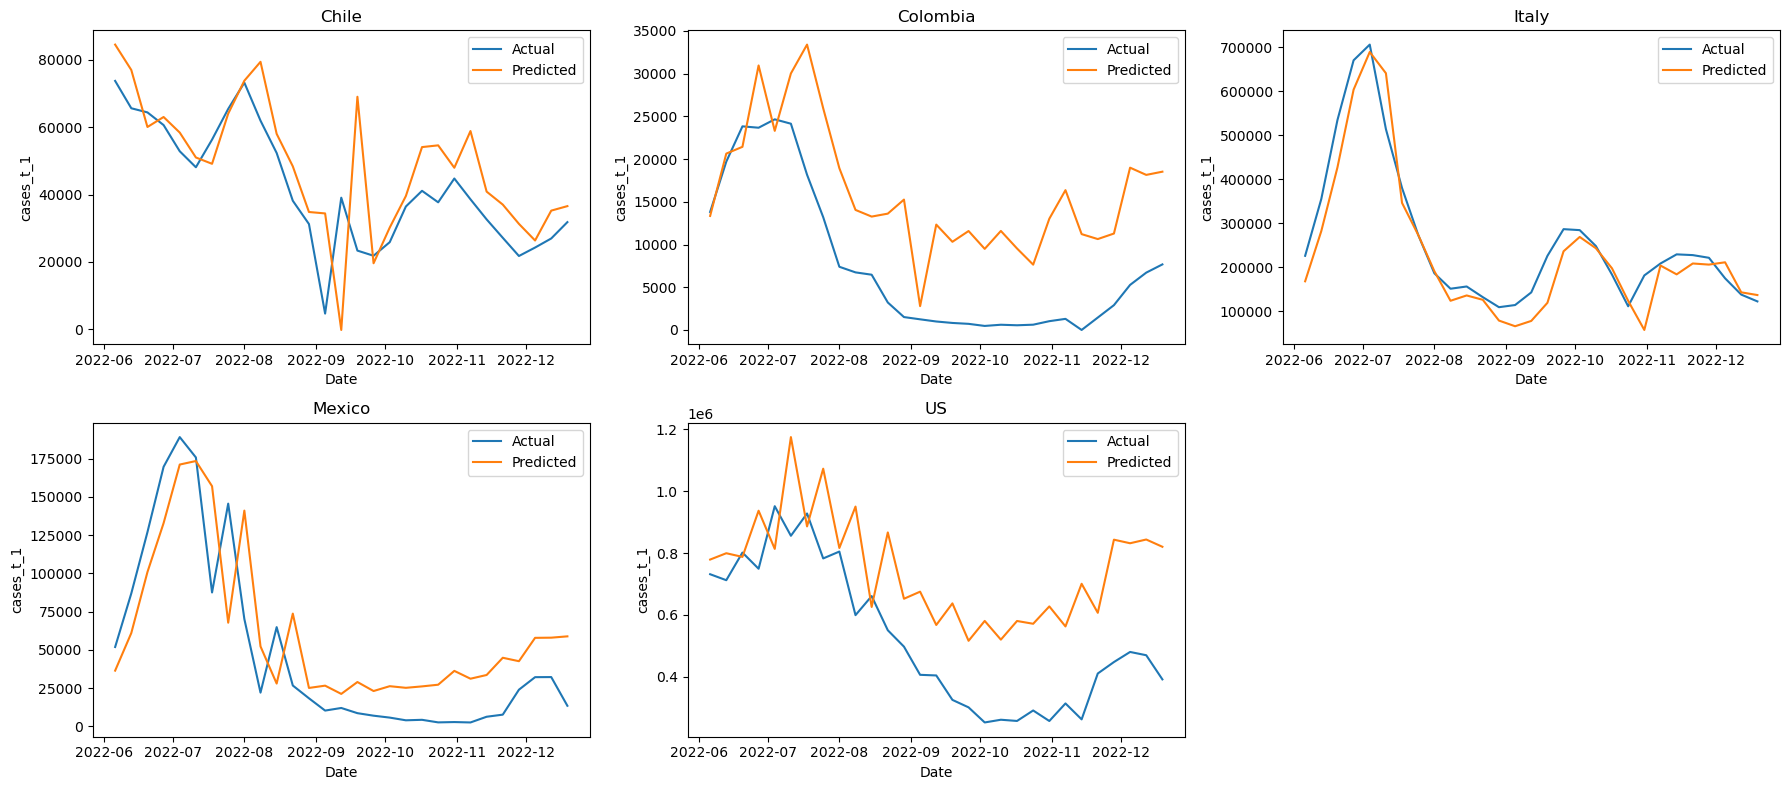

In [38]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → RidgeCV
    inner_cv = TimeSeriesSplit(n_splits=3)   # CV folds on TRAIN only
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           scoring='neg_root_mean_squared_error'))
    ])

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )
# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [39]:
# save the fitted values
fitted_df.to_csv('../results/Ridge_covid.csv', index = True)

## Elastic Net

In [40]:
from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.101e+09, tolerance: 2.350e+07
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 48602987.52302647, tolerance: 22496587.795071267
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.654e+10, tolerance: 6.592e+08


    country           rmse        r2     alpha
0     Chile   15046.048469  0.251259  0.001000
1  Colombia    8537.269364 -0.028933  0.072790
2     Italy   52756.425139  0.887837  0.001000
3    Mexico   34412.345991  0.642865  0.006723
4        US  266716.589917 -0.428249  0.001000
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23  11143.489441  9748.548365  83321.600043   4170.289127   
2020-03-30  10932.245536  9153.452697  48342.016783  18312.119012   
2020-04-06   7875.890014  7746.511519  25619.282826  12188.515239   
2020-04-13   4093.144801 -6223.224483   9554.278881  -1219.994212   
2020-04-20   4194.257802 -4097.519461  17400.248585   4261.752504   

country                US  
date                       
2020-03-23  129946.865452  
2020-03-30  144138.098411  
2020-04-06  163140.911004  
2020-04-13  121875.847485  
2020-04-20  154342.008596  


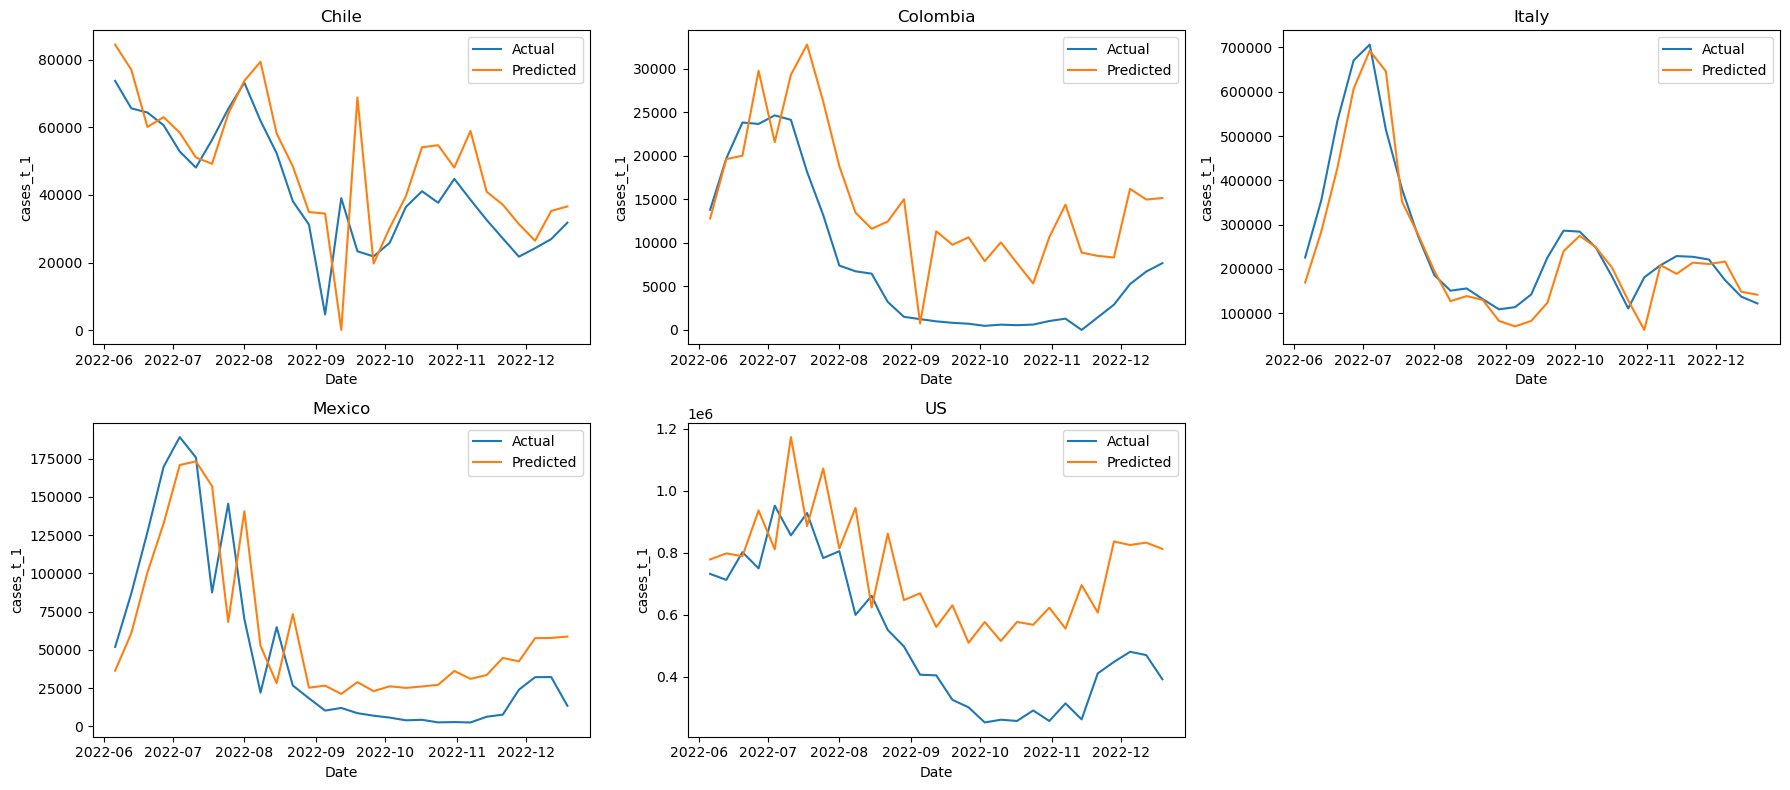

In [41]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → ElasticNetCV
    inner_cv = TimeSeriesSplit(n_splits=3)     # CV on TRAIN only
    enet_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(
                      l1_ratio     = 0.5,
                      alphas       = np.logspace(-3, 3, 30),
                      cv           = inner_cv,
                      random_state = 42,
                      max_iter     = 5000))
    ])

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [42]:
# save fitted values
fitted_df.to_csv('../results/ElasticNet_covid.csv', index = True)

## Random Forest

In [43]:
from sklearn.model_selection import  GridSearchCV
from sklearn.ensemble      import RandomForestRegressor
df = df_og.copy()

    country           rmse        r2  \
0     Chile   15927.512452  0.160960   
1  Colombia    2860.907613  0.884453   
2     Italy   90485.911172  0.670040   
3    Mexico   36497.108178  0.598283   
4        US  122735.924558  0.697554   

                                         best_params  
0  {'bootstrap': True, 'max_depth': None, 'max_fe...  
1  {'bootstrap': False, 'max_depth': None, 'max_f...  
2  {'bootstrap': False, 'max_depth': None, 'max_f...  
3  {'bootstrap': False, 'max_depth': None, 'max_f...  
4  {'bootstrap': True, 'max_depth': None, 'max_fe...  
country           Chile     Colombia    Italy       Mexico           US
date                                                                   
2020-03-23  7813.278000  1045.885069  31259.0  1878.260625  195896.7750
2020-03-30  3456.560700  1035.701625  27415.0  1966.961667  215020.2575
2020-04-06  3413.778158  1035.701625  22609.0  1966.961667  201665.9950
2020-04-13  3614.707068  1403.374125  18703.0  6177.819583  203451.37

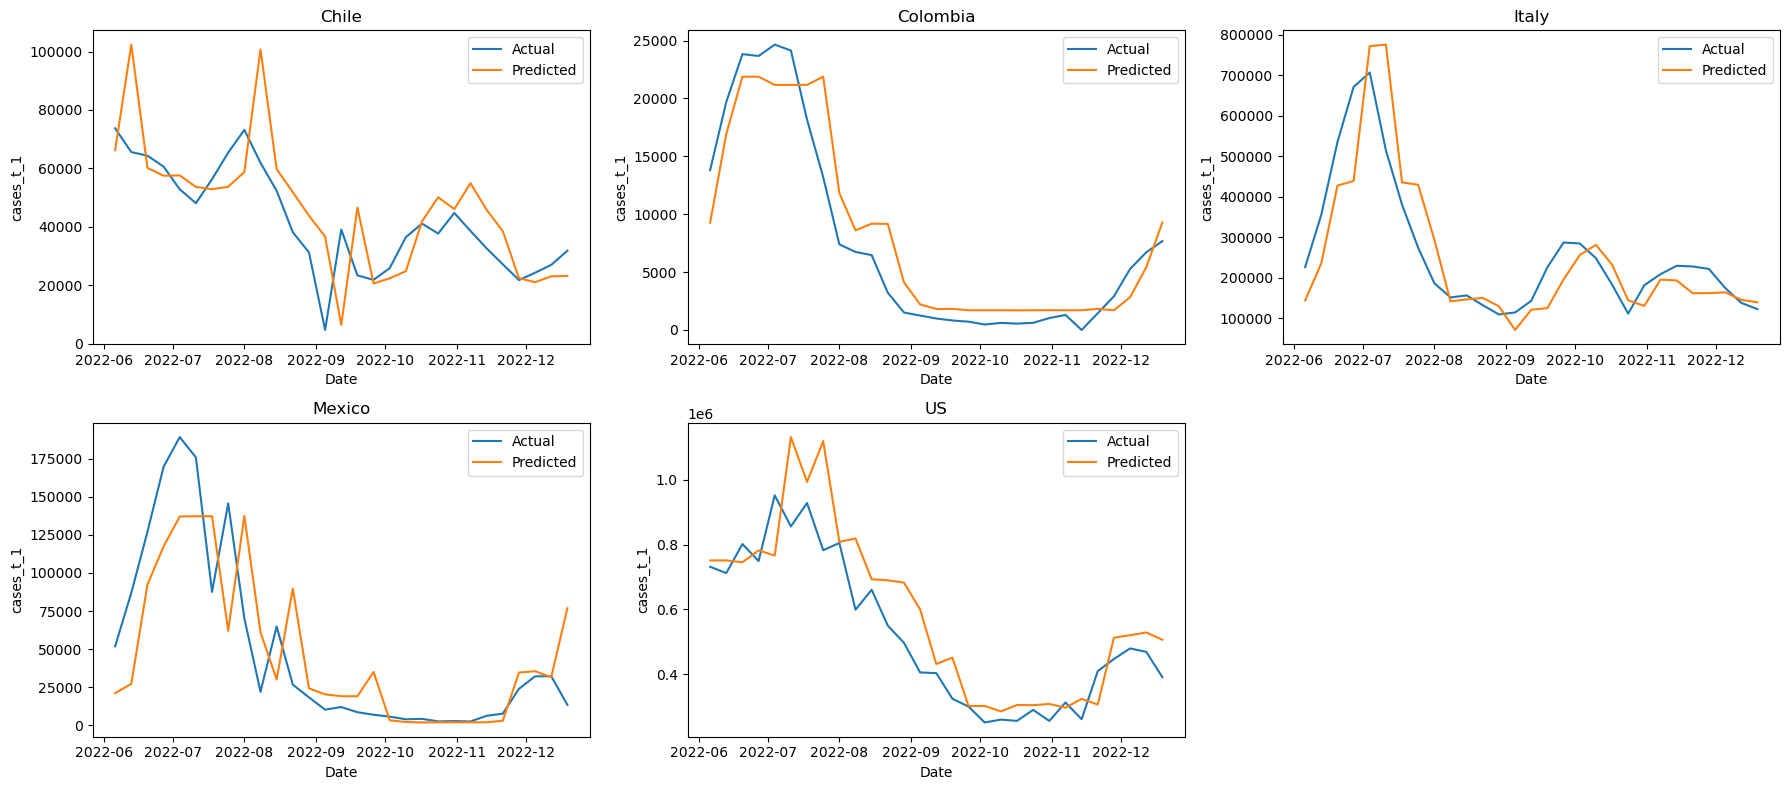

In [44]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (start coarse → tighten later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6, 0.8],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Inner CV: GridSearch over RF on TRAIN only ----
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [46]:
fitted_df.to_csv('../results/RF_covid.csv', index = True)

## Gradient Boosting

In [47]:
from sklearn.ensemble      import GradientBoostingRegressor
df = df_og.copy()

    country           rmse        r2  \
0     Chile   15330.708999  0.222659   
1  Colombia    4042.795576  0.769265   
2     Italy   80082.372038  0.741552   
3    Mexico   29018.240209  0.746051   
4        US  362328.120922 -1.635773   

                                         best_params  
0  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
1  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
2  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
3  {'learning_rate': 0.03, 'max_depth': 4, 'max_f...  
4  {'learning_rate': 0.1, 'max_depth': 4, 'max_fe...  
country            Chile     Colombia         Italy       Mexico  \
date                                                               
2020-03-23  20932.234739   839.649762  32287.088327  2053.772507   
2020-03-30  -3488.856006  1022.102797  26908.399359  4347.906280   
2020-04-06    226.988632  1502.008333  21699.972424  5296.540255   
2020-04-13   1729.529846  1473.728233  18522.912376  6634.191772   
2020-04-20   6126.315

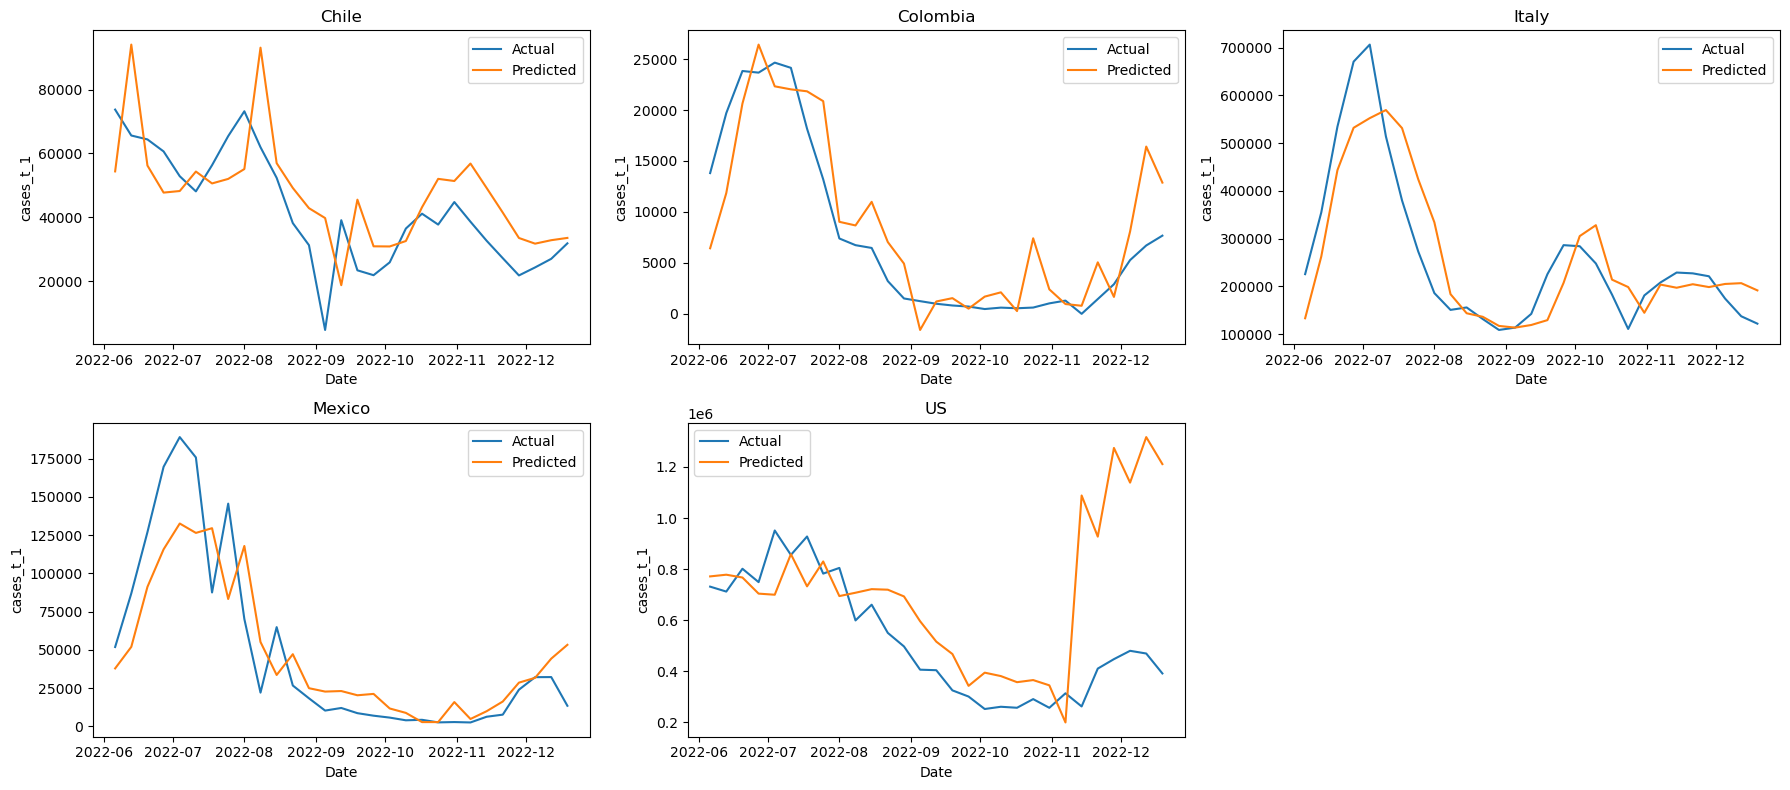

In [48]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for hold‑out plots
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [200, 400, 800],
    "learning_rate":     [0.03, 0.05, 0.1],
    "max_depth":         [2, 3, 4],        # depth of individual trees
    "subsample":         [0.7, 0.9, 1.0],
    "min_samples_leaf":  [1, 3, 5],
    "max_features":      ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Grid‑search GBM on training portion ------------
    inner_cv = TimeSeriesSplit(n_splits=3)     # folds inside TRAIN only
    gb_base  = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator  = gb_base,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics ------------------------------
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test) -----------
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )


# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [49]:
fitted_df.to_csv('../results/GB_covid.csv', index = True)

## SVM

In [50]:

from sklearn.svm            import SVR
df = df_og.copy()


    country           rmse        r2  \
0     Chile   20334.431533 -0.367574   
1  Colombia    8821.206431 -0.098513   
2     Italy  231748.100782 -1.164369   
3    Mexico   48636.072581  0.286621   
4        US  231867.810966 -0.079406   

                                         best_params  
0  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
1  {'model__C': 50, 'model__epsilon': 0.2, 'model...  
2  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
3  {'model__C': 50, 'model__epsilon': 0.2, 'model...  
4  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
country            Chile      Colombia         Italy        Mexico  \
date                                                                 
2020-03-23  22330.041005  33549.519294  56993.650975  36505.618928   
2020-03-30  18450.814758  31581.499560  55825.500026  28926.017835   
2020-04-06  16989.361057  32338.497819  54149.976047  27877.823762   
2020-04-13  15649.067263  28097.474054  50290.459854  25223.882693   
2020-04-2

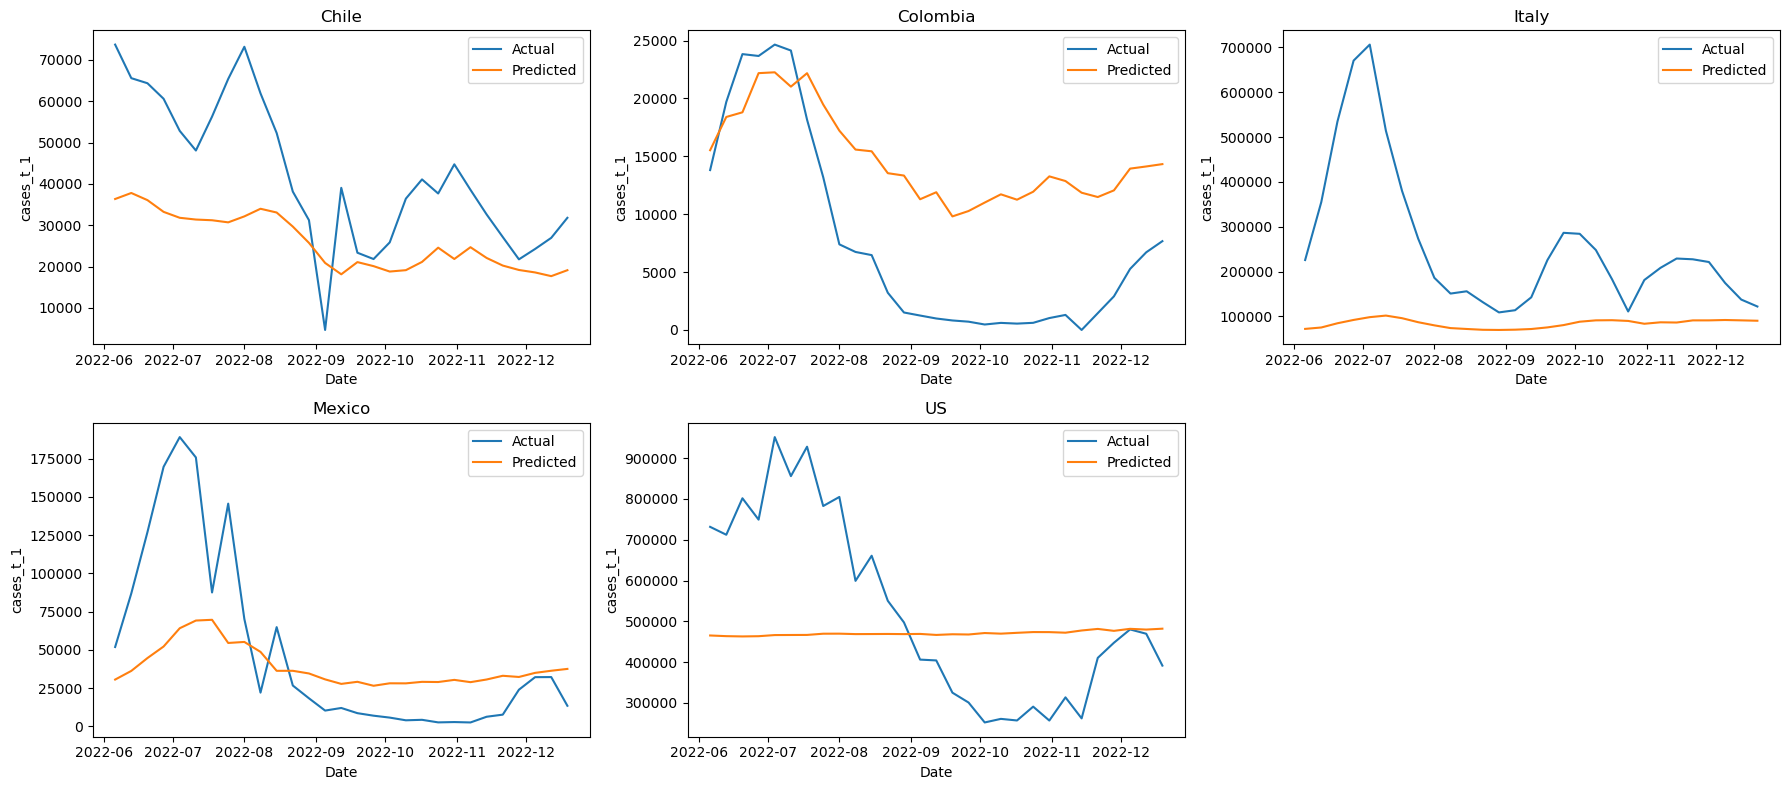

In [60]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid for SVR with an RBF kernel
#    (γ = 1 / (2σ²) in the RBF; tune together with C, ε)
# -------------------------------------------------------------
param_grid = {
    "model__C":       [0.1, 1, 10, 50],
    "model__epsilon": [0.05, 0.1, 0.2],
    "model__gamma":   ["scale", 0.01, 0.1, 1.0]  # 'scale' = 1 / (n_features * X.var)
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Pipeline: StandardScaler → SVR -----------------
    inner_cv = TimeSeriesSplit(n_splits=3)     # CV folds on TRAIN only
    svr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVR(kernel="linear"))          # RBF to match the grid
    ])

    grid = GridSearchCV(
        estimator  = svr_pipe,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)

    best_svr     = grid.best_estimator_
    best_params  = grid.best_params_

    # ---- 2.5  Predict + metrics ------------------------------
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test) -----------
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )


# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [61]:
fitted_df.to_csv('../results/SVM_covid.csv', index = True)

The models dont capture the trend, even by including the laged cases (cumulative) as a regressor